# Simulation based inference on the trajectories for the 2D parameter space

I use my own `conda` environment with `torch` and [`sbi`](https://sbi.readthedocs.io).
Data is downloaded from Zenodo and stored in the `data` directory. The data is not
included in the repository, but can be downloaded from the Zenodo link provided in the
README.

An earlier version of this notebook used [`lampe`](https://github.com/probabilists/lampe).
Development of `lampe` has stopped in favour of `sbi`, so every step below is now done
with `sbi` instead: it covers the same NPE algorithm, plus the training loop, the
plotting and a much larger set of calibration checks.

The same workflow is available as a command line script in
[`scripts/npe_2d_sbi.py`](../scripts/npe_2d_sbi.py), which is the convenient way to run
it on a cluster.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

import sbi
from sbi.analysis import pairplot, plot_tarp, sbc_rank_plot
from sbi.diagnostics import check_sbc, check_tarp, run_sbc, run_tarp
from sbi.inference import NPE
from sbi.neural_nets import posterior_nn
from sbi.neural_nets.embedding_nets import FCEmbedding, PermutationInvariantEmbedding
from sbi.utils import BoxUniform

print(f"sbi   {sbi.__version__}")
print(f"torch {torch.__version__}")

sbi   0.27.0
torch 2.13.0


In [2]:
# nicer plot settings (this replaces `lampe.plots.nice_rc`)
plt.rcParams.update({"figure.dpi": 100, "font.size": 11})

LABELS = [r"$\Delta$", r"$\Omega$"]

## Configuration

Everything that one may want to change when re-running the notebook lives in this cell.

In [3]:
DATAPATH = "../data/training-trajectories/2D-delta-omega/"

NUM_TRAIN = 512_000  # pairs used for training, as in the `lampe` version
NUM_DIAGNOSTIC = 256  # held-out pairs used for the calibration checks
OBS_INDEX = 1_000_000  # an example observation, outside both slices above
MAX_NUM_EPOCHS = 50

SEED = 0
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

torch.manual_seed(SEED)
np.random.seed(SEED)
print(f"Running on {DEVICE}")

Running on cpu


## Read training data

The parameters and the trajectories are stored in two `numpy` files. There are four
million pairs and we only need a slice of them, so we memory-map the files and read the
slices we want instead of loading everything into RAM.

In [4]:
params = np.load(DATAPATH + "param_rand_list-2D.npy", mmap_mode="r")
taus = np.load(DATAPATH + "taus-2D.npy", mmap_mode="r")

The `params` have been generated from a uniform prior distribution and the `taus` are
generated by a simulator that solves the Master Equation of the TLS and returns single
trajectories with jumps.

In [5]:
print(f"We have {len(params)} trajectories")

We have 4000000 trajectories


In [6]:
params.shape, taus.shape

((4000000, 2), (4000000, 48))

In [7]:
params.max(axis=0), params.min(axis=0)

(array([2.99999929, 4.99999964]), array([5.95611374e-07, 2.50000203e-01]))

### Plot samples from the training data

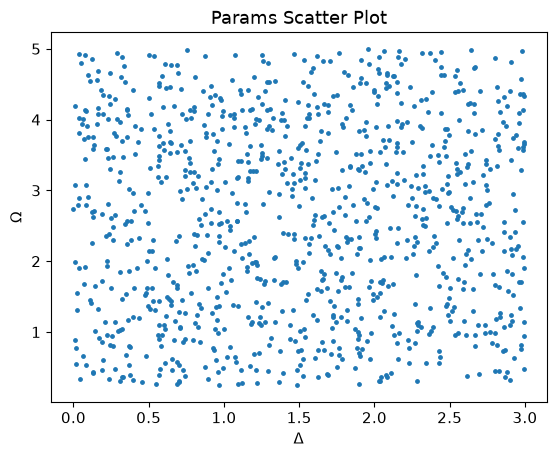

In [8]:
params_2d = np.asarray(params[:1000])  # Select the first 1000 points

plt.scatter(params_2d[:, 0], params_2d[:, 1], s=6)
plt.xlabel(LABELS[0])
plt.ylabel(LABELS[1])
plt.title("Params Scatter Plot")
plt.show()

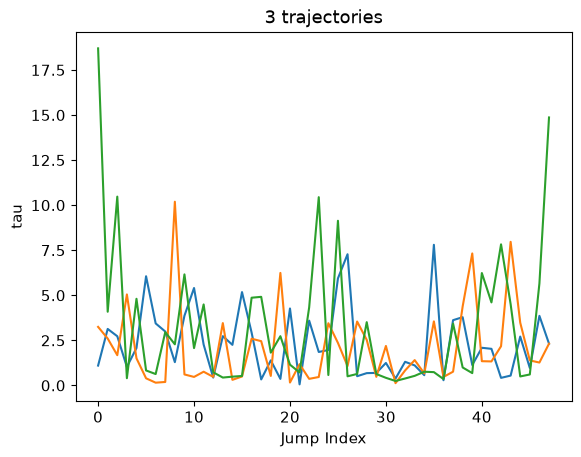

In [11]:
# Select 3 elements from taus
elements = np.asarray(taus[:3])

# Plot the elements as lines
for element in elements:
    plt.plot(element)

# Add labels and title
plt.xlabel("Jump Index")
plt.ylabel("tau")
plt.title("3 trajectories")

# Show the plot
plt.show()

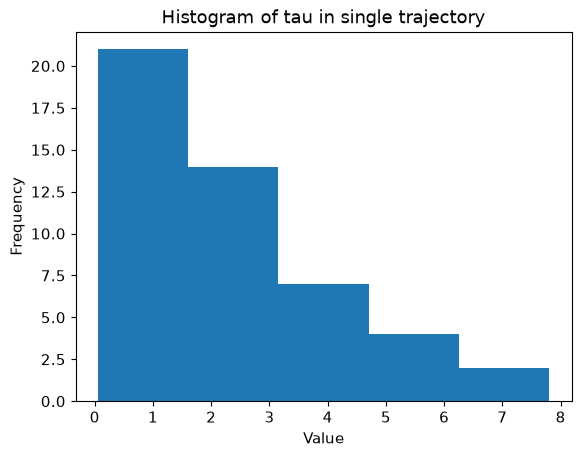

In [12]:
element_index = 0  # Index of the element in taus
element = np.asarray(taus[element_index])  # Get the element from taus

plt.hist(element, bins=5)
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram of tau in single trajectory")
plt.show()

### Prepare the pairs for `sbi`

In `sbi` the trainer takes the two tensors directly through
`append_simulations`, and does the batching, the shuffling and the train/validation
split itself. The only shape rule to respect is that `theta` has shape
`(num_pairs, dim_theta)`, that `x` has shape `(num_pairs, *x_shape)`, and that row `i`
of `x` is the trajectory simulated from row `i` of `theta`.

We cut three disjoint slices: one for training, one for the calibration checks at the
end, and a single pair to use as an example observation.

In [ ]:
assert NUM_TRAIN + NUM_DIAGNOSTIC <= len(params)
assert NUM_TRAIN + NUM_DIAGNOSTIC <= OBS_INDEX < len(params)

theta_train = torch.tensor(np.asarray(params[:NUM_TRAIN]), dtype=torch.float32)
x_train = torch.tensor(np.asarray(taus[:NUM_TRAIN]), dtype=torch.float32)

theta_train.shape, x_train.shape

(torch.Size([512000, 2]), torch.Size([512000, 48]))

The data is very high dimensional! 48 dimensions! These can be treated as 48 independent samples or they can be summarized in a histogram with their frequencies (using an embedding network).
See `build_embedding_net` in [scripts/npe_2d_sbi.py](../scripts/npe_2d_sbi.py).

### The prior

`sbi` wants to know the prior the parameters were drawn from: it uses it to reject
samples that fall outside the parameter box, and (below) to map the bounded parameters
to an unconstrained space. The detuning $\Delta$ was drawn uniformly in $[0, 3]$ and the
drive amplitude $\Omega$ uniformly in $[0.25, 5]$, which is what the minimum and maximum
of `params` printed above show.

In [14]:
LOWER = torch.tensor([0.0, 0.25])
UPPER = torch.tensor([3.0, 5.0])

prior = BoxUniform(low=LOWER, high=UPPER, device=DEVICE)
prior

BoxUniform(Uniform(low: torch.Size([2]), high: torch.Size([2])), 1)

## Train NPE

Training an NPE model with `sbi` follows the tutorial in its documentation:
[https://sbi.readthedocs.io/en/latest/tutorials/00_getting_started.html](https://sbi.readthedocs.io/en/latest/tutorials/00_getting_started.html)

There are three objects involved, and it is worth keeping them apart:

- the **density estimator**, a normalizing flow $q_\phi(\theta \mid x)$, built by
  `posterior_nn`.
- the **trainer**, `sbi.inference.NPE`, which owns the pairs and the optimisation;
- the **posterior**, returned by `build_posterior`, which is what we sample from.

In [19]:
estimator_builder = posterior_nn(
    model="nsf",  # a Neural Spline Flow (NSF) model
    hidden_features=128,
    num_transforms=3,
    z_score_theta="independent",
    z_score_x="structured",
    x_dist=prior,
)

Two of those arguments deserve a comment:

`z_score_theta="transform_to_unconstrained"` is equivalent to rescaling $\theta$ to
$[-1, 1]$ before training and undoing the rescaling after sampling. `sbi` folds that step
into the flow itself, so the samples come back in physical units and there is no
postprocessing to forget. It goes one step further than a rescaling, though: it maps the
bounded box to an unbounded space, so the flow cannot put mass outside the prior and
there is nothing to reject. The bounds come from the distribution passed as `x_dist`,
which for NPE is the prior (`x` here names the variable the flow models, which is
$\theta$; the observation is the conditioning variable). 
This requires a `model="zuko_nsf"` from the `zuko` library.

`z_score_x="structured"` standardises the trajectory with a single mean and standard
deviation shared across the 48 jumps, rather than one per jump. That is the right choice
here because every entry of a trajectory is the same physical quantity — a time delay —
so they should be treated as 48 draws of one distribution, not as 48 unrelated features.

In [20]:
trainer = NPE(prior=prior, density_estimator=estimator_builder, device=DEVICE)
trainer.append_simulations(theta_train, x_train)

In the case of NPE, the loss to minimize is the expected negative log-likelihood of the
data. The trainer takes care of doing the training loop, including an early stopping criterium on a held-out validation set.

In [21]:
density_estimator = trainer.train(
    training_batch_size=256,
    learning_rate=1e-3,
    validation_fraction=0.1,
    stop_after_epochs=20,
    max_num_epochs=MAX_NUM_EPOCHS,
    clip_max_norm=1.0,
    show_train_summary=True,
)

 Neural network successfully converged after 48 epochs.
        -------------------------
        ||||| ROUND 1 STATS |||||:
        -------------------------
        Epochs trained: 48
        Best validation performance: 0.9358
        -------------------------
        


In [22]:
posterior = trainer.build_posterior(density_estimator)
posterior

DirectPosterior sampler for potential_fn=<PosteriorBasedPotential>

## Quick evaluation

We take a datapoint from the training data saved on disk that has not actually been used for training
and evaluate the NPE model on it.

In [23]:
theta_star = torch.tensor(np.asarray(params[OBS_INDEX]), dtype=torch.float32).to(DEVICE)
x_star = torch.tensor(np.asarray(taus[OBS_INDEX]), dtype=torch.float32).to(DEVICE)

theta_star

tensor([2.6388, 2.5674])

Sampling is one call: the posterior is amortized, so conditioning it on a new
observation costs nothing beyond the forward pass. This replaces
`estimator.flow(x_star).sample(...)` followed by `postprocess`.

In [24]:
samples = posterior.sample((2**14,), x=x_star)
samples.shape

  0%|          | 0/16384 [00:00<?, ?it/s]

/Users/enrico.rinaldi/miniforge3/envs/torch-sbi/lib/python3.11/site-packages/nflows/transforms/lu.py:80: UserWarning: torch.triangular_solve is deprecated in favor of torch.linalg.solve_triangularand will be removed in a future PyTorch release.
torch.linalg.solve_triangular has its arguments reversed and does not return a copy of one of the inputs.
X = torch.triangular_solve(B, A).solution
should be replaced with
X = torch.linalg.solve_triangular(A, B). (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/native/BatchLinearAlgebra.cpp:2279.)
  outputs, _ = torch.triangular_solve(


torch.Size([16384, 2])

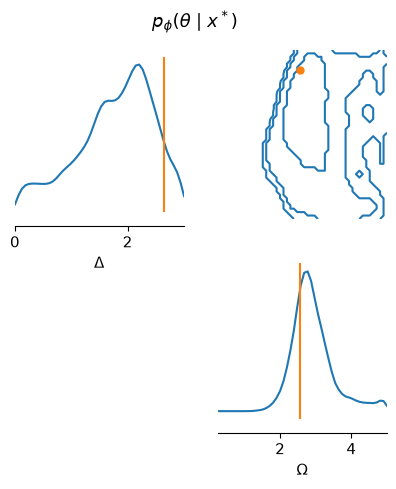

In [25]:
fig, ax = pairplot(
    samples.cpu(),
    points=theta_star.cpu().reshape(1, -1),
    limits=[[LOWER[0], UPPER[0]], [LOWER[1], UPPER[1]]],
    labels=LABELS,
    upper="contour",
    diag="kde",
    figsize=(4.8, 4.8),
)
fig.suptitle(r"$p_\phi(\theta \mid x^*)$")
plt.show()

In [26]:
print(f"ground truth    : {theta_star.tolist()}")
print(f"posterior mean  : {samples.mean(dim=0).tolist()}")
print(f"posterior std   : {samples.std(dim=0).tolist()}")

ground truth    : [2.638829231262207, 2.5673580169677734]
posterior mean  : [1.7486600875854492, 2.914710283279419]
posterior std   : [0.7107827067375183, 0.5915884971618652]


## Calibration checks

A trained flow always returns samples, and nothing about them says whether they are the
posterior. We can run three complementary checks.

All three are averages over the prior predictive, which is exactly what our held-out
pairs are: `params` was drawn from the prior and `taus` was simulated from it. So the
checks cost no new simulations — we just reuse the `NUM_DIAGNOSTIC` pairs we set aside.

In [27]:
# The training pairs stay on the CPU, because `train` moves them one mini-batch
# at a time. The held-out pairs are handed to the *trained* posterior instead,
# and `sbi` leaves a tensor passed to `sample(x=...)` on whatever device it is
# already on, so those have to be moved here.
diag = slice(NUM_TRAIN, NUM_TRAIN + NUM_DIAGNOSTIC)
theta_diag = torch.tensor(np.asarray(params[diag]), dtype=torch.float32).to(DEVICE)
x_diag = torch.tensor(np.asarray(taus[diag]), dtype=torch.float32).to(DEVICE)

### Simulation-based calibration (SBC)

SBC ranks the true parameter among the posterior samples, once per held-out pair. If the
posterior is calibrated, those ranks are uniform. The rank histogram is read per
parameter: flat means we cannot reject calibration, U-shaped means the posterior is too
narrow (over-confident), and ∩-shaped means it is too wide.

In [28]:
ranks, dap_samples = run_sbc(
    theta_diag, x_diag, posterior, num_posterior_samples=1_000
)
# `run_sbc` hands its ranks back on the posterior's device; the check below and
# the rank plots go through numpy, so bring them home first.
ranks, dap_samples = ranks.cpu(), dap_samples.cpu()

stats = check_sbc(ranks, theta_diag.cpu(), dap_samples, num_posterior_samples=1_000)
stats

/Users/enrico.rinaldi/miniforge3/envs/torch-sbi/lib/python3.11/site-packages/sbi/utils/diagnostics_utils.py:45: UserWarning: Capping max_sampling_batch_size from 10000 to 390 to avoid excessive memory usage.
  posterior_samples = posterior.sample_batched(


Drawing 1000 samples for 256 observations:   0%|          | 0/1000 [00:00<?, ?it/s]

Calculating ranks for 256 SBC samples:   0%|          | 0/256 [00:00<?, ?it/s]

{'ks_pvals': tensor([0.4014, 0.4278]),
 'c2st_ranks': tensor([0.5078, 0.5235], dtype=torch.float64),
 'c2st_dap': tensor([0.4806, 0.5197], dtype=torch.float64)}

`ks_pvals` is a Kolmogorov-Smirnov p-value per parameter against uniform ranks: below
about 0.05 flags miscalibration. `c2st_ranks` trains a classifier to tell the ranks from
uniform ones, so 0.5 is perfect and above about 0.6 is a problem. `c2st_dap` compares the
data-averaged posterior with the prior, and should also sit near 0.5.

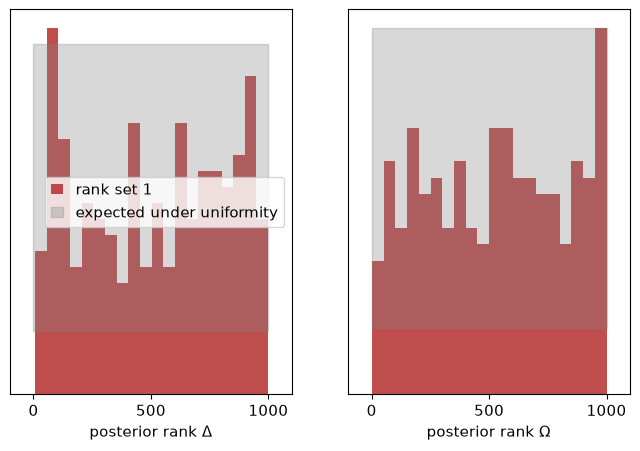

In [29]:
fig, ax = sbc_rank_plot(
    ranks, 1_000, plot_type="hist", num_bins=20, parameter_labels=LABELS
)
plt.show()

### Expected coverage

In `sbi` the expected coverage is the
same machinery as SBC with one argument changed: rank the joint log-probability instead
of each marginal. Because it uses the joint, it also sees errors in the correlations
between $\Delta$ and $\Omega$ that the per-parameter histograms above cannot.

/Users/enrico.rinaldi/miniforge3/envs/torch-sbi/lib/python3.11/site-packages/sbi/utils/diagnostics_utils.py:45: UserWarning: Capping max_sampling_batch_size from 10000 to 390 to avoid excessive memory usage.
  posterior_samples = posterior.sample_batched(


Drawing 1000 samples for 256 observations:   0%|          | 0/1000 [00:00<?, ?it/s]

Calculating ranks for 256 SBC samples:   0%|          | 0/256 [00:00<?, ?it/s]

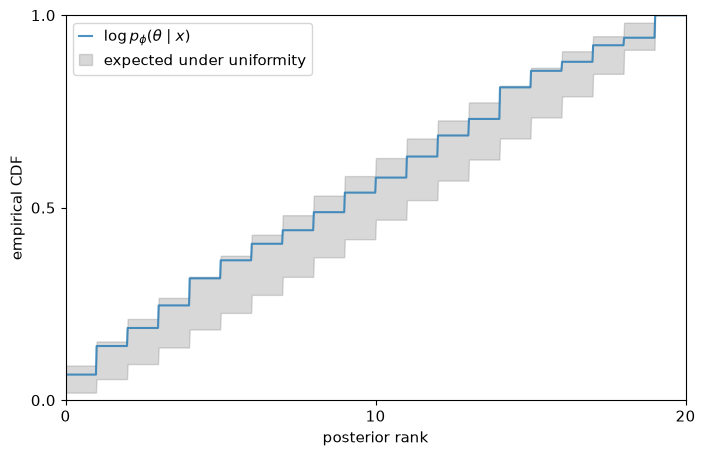

In [30]:
coverage_ranks, _ = run_sbc(
    theta_diag,
    x_diag,
    posterior,
    num_posterior_samples=1_000,
    reduce_fns=posterior.log_prob,
)
coverage_ranks = coverage_ranks.cpu()

fig, ax = sbc_rank_plot(
    coverage_ranks,
    1_000,
    plot_type="cdf",
    num_bins=20,
    parameter_labels=[r"$\log p_\phi(\theta \mid x)$"],
)
plt.show()

Being below the diagonal means having an estimator of the posterior that is
overconfident. This can happen for many reasons, such as overfitting on training data.

Being above the diagonal means having a posterior that is underconfident. It is broader than it needs to be.

### TARP

TARP (Tests of Accuracy with Random Points) is the strongest of the three: unlike SBC it
is a necessary *and* sufficient condition for the posterior to be correct, so it also
catches posteriors that are calibrated on average but inaccurate. We want `atc` close to
zero and `ks_pval` above 0.05.

In [31]:
ecp, alpha = run_tarp(theta_diag, x_diag, posterior, num_posterior_samples=1_000)
ecp, alpha = ecp.cpu(), alpha.cpu()

atc, ks_pval = check_tarp(ecp, alpha)
print(f"area to curve (want ~0) : {atc:.4f}")
print(f"KS p-value    (want >.05): {ks_pval:.4f}")

Drawing 1000 samples for 256 observations:   0%|          | 0/1000 [00:00<?, ?it/s]

area to curve (want ~0) : -0.0117
KS p-value    (want >.05): 1.0000


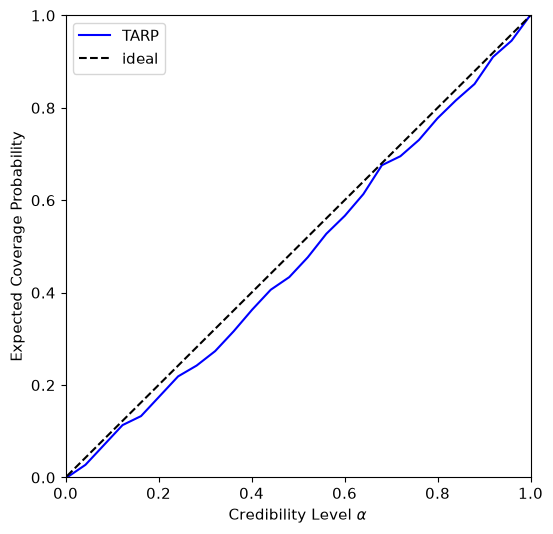

In [32]:
fig, ax = plot_tarp(ecp, alpha)
plt.show()

## Embedding network

We can pre-process the trajectories of 48 jumps and extract a lower-dimensional summary
statistic using an embedding network.

In our case we can use an embedding network that is manifestly permutation invariant,
such as DeepSets. `sbi` ships one as
`PermutationInvariantEmbedding`: a `trial_net` applied to
every single time delay, a sum over the jumps, and a second network mapping the sum to
the summary.

In [33]:
LATENT_DIM = 16  # dimension of the per-jump features
FEATURE_DIM = 4  # dimension of the summary handed to the flow: keep this small. 

trial_net = FCEmbedding(
    input_dim=1,  # a single tau in the trajectory is a scalar
    num_hiddens=64,
    num_layers=2,
    output_dim=LATENT_DIM,
) # there is probably no reason to take a one-dimensional (scalar) tau and embed it into a 16-dimensional latent space

embedding_net = PermutationInvariantEmbedding(
    trial_net,
    trial_net_output_dim=LATENT_DIM,
    aggregation_fn="sum",
    num_hiddens=64,
    num_layers=2,
    output_dim=FEATURE_DIM,
)

embedding_net

PermutationInvariantEmbedding(
  (trial_net): FCEmbedding(
    (net): Sequential(
      (0): Linear(in_features=1, out_features=64, bias=True)
      (1): Identity()
      (2): ReLU()
      (3): Linear(in_features=64, out_features=16, bias=True)
      (4): ReLU()
    )
  )
  (fc_subnet): FCEmbedding(
    (net): Sequential(
      (0): Linear(in_features=17, out_features=64, bias=True)
      (1): Identity()
      (2): ReLU()
      (3): Linear(in_features=64, out_features=4, bias=True)
      (4): ReLU()
    )
  )
)

The embedding expects an explicit trial axis, so the trajectories become
`(num_pairs, 48, 1)` instead of `(num_pairs, 48)`: 48 trials of a one-dimensional
observation, rather than one 48-dimensional observation.

In [34]:
x_train_set = x_train.unsqueeze(-1)
x_diag_set = x_diag.unsqueeze(-1)
x_star_set = x_star.unsqueeze(-1)

x_train_set.shape, x_star_set.shape

(torch.Size([512000, 48, 1]), torch.Size([48, 1]))

In [35]:
# check that the summary has the expected dimension. The embedding is still
# on the CPU at this point: `sbi` moves it to DEVICE when it builds the
# estimator below, so the trajectory comes back to the host just for this.
embedding_net(x_star_set.cpu().unsqueeze(0)).shape

torch.Size([1, 4])

Create the NPE estimator including the embedding network. The embedding attaches to the
density estimator, not to the trainer, and is trained jointly with the flow.

In [36]:
em_builder = posterior_nn(
    model="nsf",
    hidden_features=64,
    num_transforms=3,
    z_score_theta="independent",
    z_score_x="independent",
    x_dist=prior,
    embedding_net=embedding_net,
)

em_trainer = NPE(prior=prior, density_estimator=em_builder, device=DEVICE)
em_trainer.append_simulations(theta_train, x_train_set)

/Users/enrico.rinaldi/miniforge3/envs/torch-sbi/lib/python3.11/site-packages/sbi/inference/trainers/npe/npe_base.py:211: UserWarning: Data has extreme outliers in dimension(s) [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47] (beyond 10.0x IQR from quartiles). This may cause precision loss during z-scoring, where distinct values become indistinguishable. Consider removing outliers from your data or setting `z_score_x='none'` (though this may affect training).
  warn_if_invalid_for_zscoring(x)


Training

In [37]:
em_density_estimator = em_trainer.train(
    training_batch_size=256,
    learning_rate=1e-3,
    validation_fraction=0.1,
    stop_after_epochs=20,
    max_num_epochs=MAX_NUM_EPOCHS,
    clip_max_norm=1.0,
    show_train_summary=True,
)

em_posterior = em_trainer.build_posterior(em_density_estimator)

 Training neural network. Epochs trained: 51
        -------------------------
        ||||| ROUND 1 STATS |||||:
        -------------------------
        Epochs trained: 51
        Best validation performance: 0.3268
        -------------------------
        


/var/folders/ws/cqf8ldqx2mj57mc_bxqhswcc0000gq/T/ipykernel_50090/860112003.py:1: UserWarning: Maximum number of epochs `max_num_epochs=50` reached, but network has not yet fully converged. Consider increasing it.
  em_density_estimator = em_trainer.train(


  0%|          | 0/16384 [00:00<?, ?it/s]

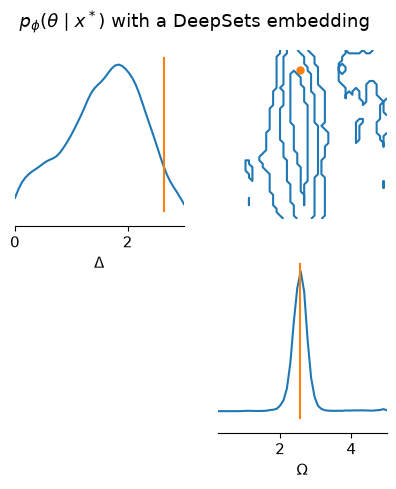

In [38]:
em_samples = em_posterior.sample((2**14,), x=x_star_set)

fig, ax = pairplot(
    em_samples.cpu(),
    points=theta_star.cpu().reshape(1, -1),
    limits=[[LOWER[0], UPPER[0]], [LOWER[1], UPPER[1]]],
    labels=LABELS,
    upper="contour",
    diag="kde",
    figsize=(4.8, 4.8),
)
fig.suptitle(r"$p_\phi(\theta \mid x^*)$ with a DeepSets embedding")
plt.show()

The interesting comparison is not the posterior at a single observation but the
calibration, so we run the same checks on the embedding model and compare the numbers
with the ones above.

In [39]:
em_ranks, em_dap = run_sbc(
    theta_diag, x_diag_set, em_posterior, num_posterior_samples=1_000
)
em_ranks, em_dap = em_ranks.cpu(), em_dap.cpu()
em_stats = check_sbc(em_ranks, theta_diag.cpu(), em_dap, num_posterior_samples=1_000)

em_ecp, em_alpha = run_tarp(
    theta_diag, x_diag_set, em_posterior, num_posterior_samples=1_000
)
em_ecp, em_alpha = em_ecp.cpu(), em_alpha.cpu()
em_atc, em_ks = check_tarp(em_ecp, em_alpha)

rows = [
    (r"KS p-value  Delta", stats["ks_pvals"][0], em_stats["ks_pvals"][0]),
    (r"KS p-value  Omega", stats["ks_pvals"][1], em_stats["ks_pvals"][1]),
    (r"C2ST ranks  Delta", stats["c2st_ranks"][0], em_stats["c2st_ranks"][0]),
    (r"C2ST ranks  Omega", stats["c2st_ranks"][1], em_stats["c2st_ranks"][1]),
    ("TARP area to curve", atc, em_atc),
    ("TARP KS p-value", ks_pval, em_ks),
]

print(f"{'':20s}{'raw trajectory':>16s}{'DeepSets':>12s}")
for name, raw, embedded in rows:
    print(f"{name:20s}{float(raw):>16.3f}{float(embedded):>12.3f}")

/Users/enrico.rinaldi/miniforge3/envs/torch-sbi/lib/python3.11/site-packages/sbi/utils/diagnostics_utils.py:45: UserWarning: Capping max_sampling_batch_size from 10000 to 390 to avoid excessive memory usage.
  posterior_samples = posterior.sample_batched(


Drawing 1000 samples for 256 observations:   0%|          | 0/1000 [00:00<?, ?it/s]

Calculating ranks for 256 SBC samples:   0%|          | 0/256 [00:00<?, ?it/s]

/Users/enrico.rinaldi/miniforge3/envs/torch-sbi/lib/python3.11/site-packages/sbi/utils/diagnostics_utils.py:45: UserWarning: Capping max_sampling_batch_size from 10000 to 390 to avoid excessive memory usage.
  posterior_samples = posterior.sample_batched(


Drawing 1000 samples for 256 observations:   0%|          | 0/1000 [00:00<?, ?it/s]

                      raw trajectory    DeepSets
KS p-value  Delta              0.401       0.580
KS p-value  Omega              0.428       0.660
C2ST ranks  Delta              0.508       0.508
C2ST ranks  Omega              0.523       0.494
TARP area to curve            -0.012       0.019
TARP KS p-value                1.000       0.997


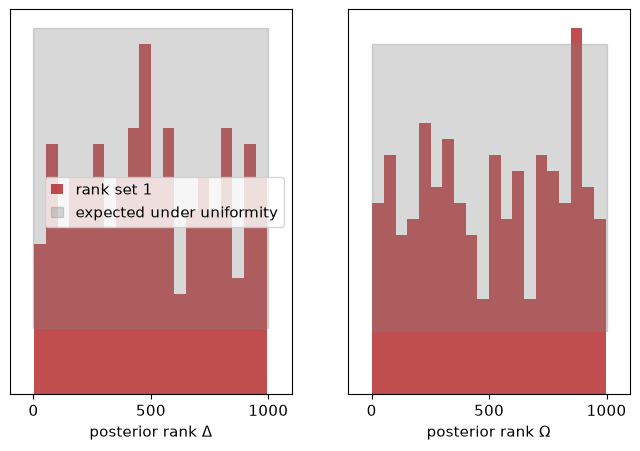

In [40]:
fig, ax = sbc_rank_plot(
    em_ranks, 1_000, plot_type="hist", num_bins=20, parameter_labels=LABELS
)
plt.show()

## Save the trained posterior

The posterior object is picklable, so it can be reloaded later without retraining and
used to estimate parameters for the validation trajectories.

In [41]:
import pickle
from pathlib import Path

outdir = Path("../data/models/npe-sbi-2D/")
outdir.mkdir(parents=True, exist_ok=True)

torch.save(density_estimator.state_dict(), outdir / "npe_density_estimator.pt")
with open(outdir / "npe_posterior.pkl", "wb") as f:
    pickle.dump(posterior, f)

print(f"saved to {outdir.resolve()}")

saved to /Users/enrico.rinaldi/Projects/ParamEst-NN/data/models/npe-sbi-2D


In [42]:
torch.save(em_density_estimator.state_dict(), outdir / "npe_em_density_estimator.pt")
with open(outdir / "npe_em_posterior.pkl", "wb") as f:
    pickle.dump(em_posterior, f)

print(f"saved to {outdir.resolve()}")

saved to /Users/enrico.rinaldi/Projects/ParamEst-NN/data/models/npe-sbi-2D
